### Instalando as Bibliotecas

import sys
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install seaborn
!{sys.executable} -m pip install plotly

### Importando Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

### Base

In [2]:
df = pd.read_csv("IDH-2010 - Página1.csv") #importando o arquivo em formato CSV

In [ ]:
df.head(5) #verificando as 5 primeiras linhas

,ANO,Código da Unidade da Federação,Nome da Unidade da Federação,Código do Município,Município,IDHM,IDHM Educação,IDHM Longevidade,IDHM Renda
0,2010,11,Rondônia,110001,ALTA FLORESTA D'OESTE,"0,641","0,526","0,763","0,657"
1,2010,11,Rondônia,110002,ARIQUEMES,"0,702","0,6","0,806","0,716"
2,2010,11,Rondônia,110003,CABIXI,"0,65","0,559","0,757","0,65"
3,2010,11,Rondônia,110004,CACOAL,"0,718","0,62","0,821","0,727"
4,2010,11,Rondônia,110005,CEREJEIRAS,"0,692","0,602","0,799","0,688"


In [4]:
df.isnull().sum() # verificando a presença de nulos em cada coluna

ANO                               0
Código da Unidade da Federação    0
Nome da Unidade da Federação      0
Código do Município               0
Município                         0
IDHM                              0
IDHM Educação                     0
IDHM Longevidade                  0
IDHM Renda                        0
dtype: int64

In [5]:
print(df.describe) #realizando uma analise estatistica

<bound method NDFrame.describe of        ANO  Código da Unidade da Federação Nome da Unidade da Federação  \
0     2010                              11                     Rondônia   
1     2010                              11                     Rondônia   
2     2010                              11                     Rondônia   
3     2010                              11                     Rondônia   
4     2010                              11                     Rondônia   
...    ...                             ...                          ...   
5559  2010                              52                        Goiás   
5560  2010                              52                        Goiás   
5561  2010                              52                        Goiás   
5562  2010                              52                        Goiás   
5563  2010                              53             Distrito Federal   

      Código do Município              Município   IDHM IDHM Educ

In [6]:
df.duplicated().sum() #verificando se valores duplicados 

np.int64(0)

In [7]:
df.shape #composição de linhas e colunas

(5564, 9)

In [8]:
df['state'] = df['Nome da Unidade da Federação'].fillna('Distrito Federal') 
#substritui valores ausentes pelo campo escolhido, serve para ajuste e limpeza dentro do dataset justamento para ajuste fino e uso do modelo

In [32]:
df.dtypes

ANO                                 int64
Código da Unidade da Federação      int64
Nome da Unidade da Federação       object
Código do Município                 int64
Município                          object
IDHM                              float64
IDHM Educação                      object
IDHM Longevidade                   object
IDHM Renda                         object
state                              object
classe                             object
dtype: object

In [10]:
df.info() #verifando o formato de cada variavel dentro do dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5564 entries, 0 to 5563
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   ANO                             5564 non-null   int64 
 1   Código da Unidade da Federação  5564 non-null   int64 
 2   Nome da Unidade da Federação    5564 non-null   object
 3   Código do Município             5564 non-null   int64 
 4   Município                       5564 non-null   object
 5   IDHM                            5564 non-null   object
 6   IDHM Educação                   5564 non-null   object
 7   IDHM Longevidade                5564 non-null   object
 8   IDHM Renda                      5564 non-null   object
 9   state                           5564 non-null   object
dtypes: int64(3), object(7)
memory usage: 434.8+ KB


### Gráfico de Histograma
serve para verificar a distribuição dos dados

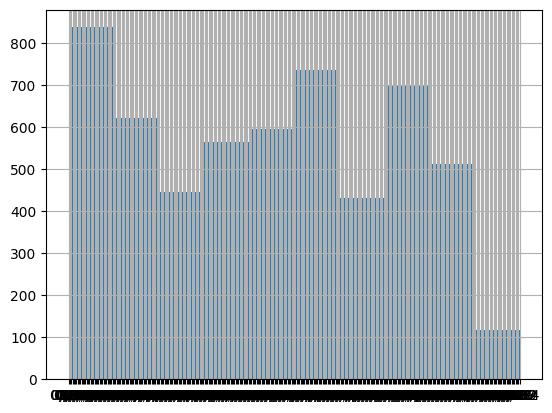

In [11]:
df['IDHM'].hist(bins=10) #histograma
plt.show()

<Axes: xlabel='Nome da Unidade da Federação', ylabel='IDHM'>

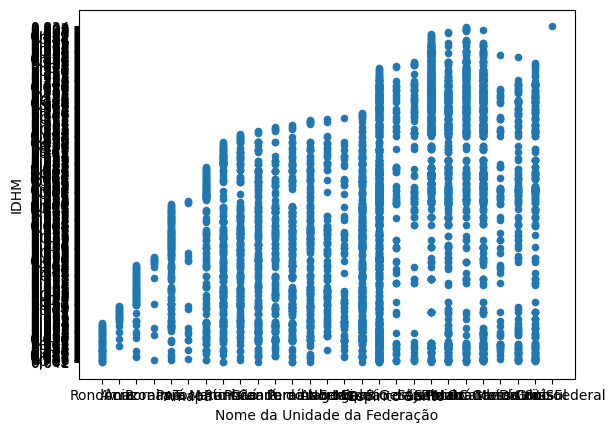

In [12]:
df.plot.scatter(x='Nome da Unidade da Federação', y='IDHM')

In [13]:
df.nunique()

ANO                                  1
Código da Unidade da Federação      27
Nome da Unidade da Federação        27
Código do Município               5564
Município                         5329
IDHM                               349
IDHM Educação                      466
IDHM Longevidade                   220
IDHM Renda                         390
state                               27
dtype: int64

In [14]:
df.describe().round(2)

,ANO,Código da Unidade da Federação,Código do Município
count,5564.0,5564.00,5564.0
mean,2010.0,32.37,325323.7
std,0.0,9.83,98451.0
min,2010.0,11.00,110001.0
25%,2010.0,25.00,251217.5
50%,2010.0,31.00,314622.5
75%,2010.0,41.00,411902.5
max,2010.0,53.00,530010.0


In [15]:
df['IDHM'] = pd.to_numeric(df['IDHM'].str.replace(',', '.'))
#transformando a string em um valor numerico

In [ ]:
def idhm_class(df):
  if df['IDHM'] <= 0.499:
    return 'Baixo desenvolvimento humano'
  elif df['IDHM'] > 0.8:
    return 'Alto desenvolvmento humano'
  else:
    return 'Médio desenvolvimento humano'

In [17]:
df["classe"] = df.apply(idhm_class, axis=1)
df.head(5)

,ANO,Código da Unidade da Federação,Nome da Unidade da Federação,Código do Município,Município,IDHM,IDHM Educação,IDHM Longevidade,IDHM Renda,state,classe
0,2010,11,Rondônia,110001,ALTA FLORESTA D'OESTE,0.641,"0,526","0,763","0,657",Rondônia,Médio desenvolvimento humano
1,2010,11,Rondônia,110002,ARIQUEMES,0.702,"0,6","0,806","0,716",Rondônia,Médio desenvolvimento humano
2,2010,11,Rondônia,110003,CABIXI,0.650,"0,559","0,757","0,65",Rondônia,Médio desenvolvimento humano
3,2010,11,Rondônia,110004,CACOAL,0.718,"0,62","0,821","0,727",Rondônia,Médio desenvolvimento humano
4,2010,11,Rondônia,110005,CEREJEIRAS,0.692,"0,602","0,799","0,688",Rondônia,Médio desenvolvimento humano


In [18]:
df['classe'].value_counts() # distribuição dos valorres da função 

classe
Médio desenvolvimento humano    5493
Alto desenvolvmento humano        39
Baixo desenvolvimento humano      32
Name: count, dtype: int64

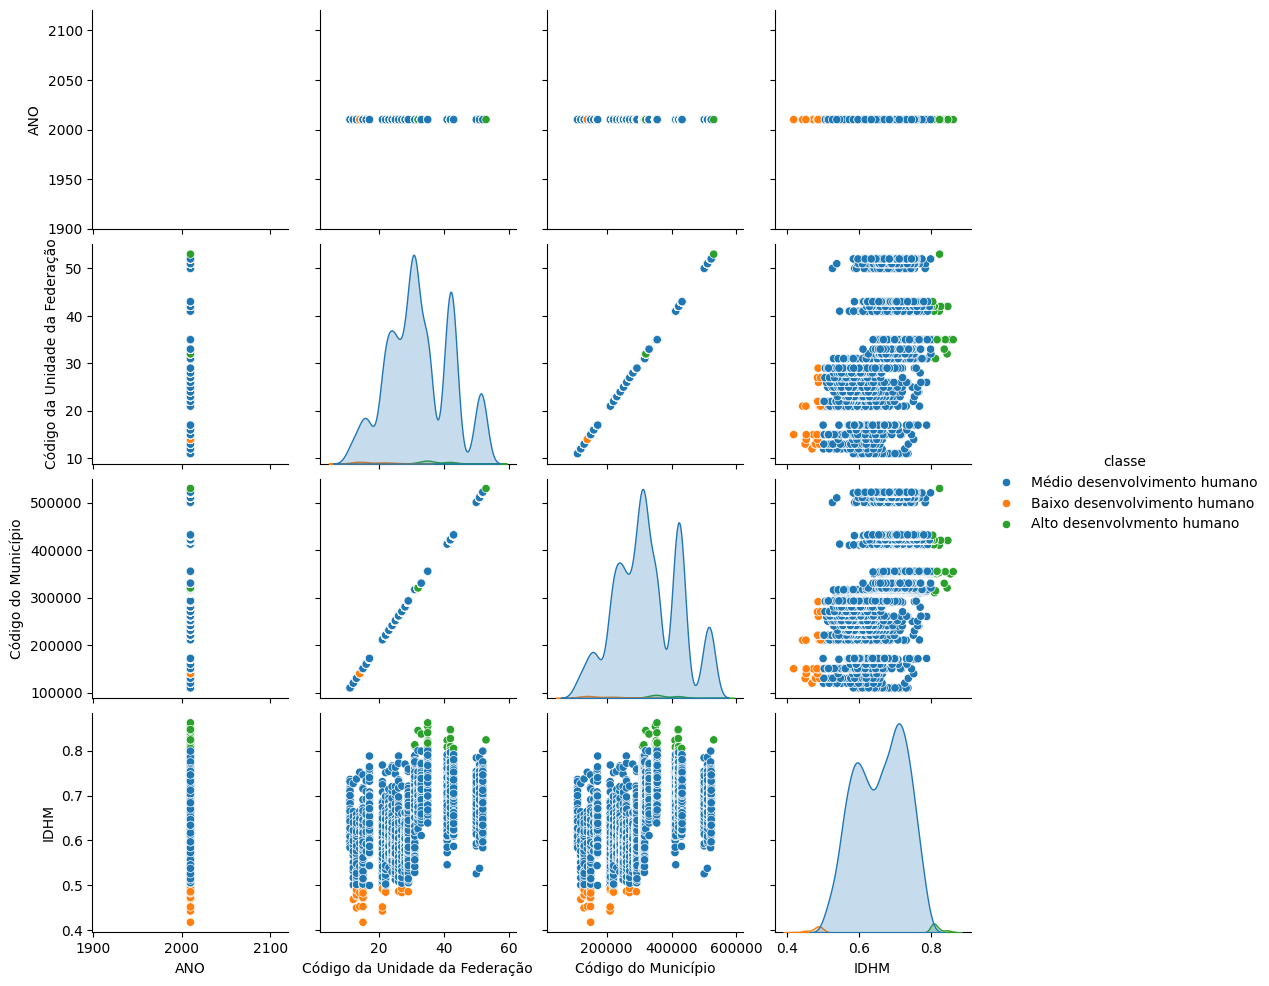

In [19]:
sns.pairplot(df, hue='classe')
#gráfico de dispersão 

In [20]:
df.head()

,ANO,Código da Unidade da Federação,Nome da Unidade da Federação,Código do Município,Município,IDHM,IDHM Educação,IDHM Longevidade,IDHM Renda,state,classe
0,2010,11,Rondônia,110001,ALTA FLORESTA D'OESTE,0.641,"0,526","0,763","0,657",Rondônia,Médio desenvolvimento humano
1,2010,11,Rondônia,110002,ARIQUEMES,0.702,"0,6","0,806","0,716",Rondônia,Médio desenvolvimento humano
2,2010,11,Rondônia,110003,CABIXI,0.650,"0,559","0,757","0,65",Rondônia,Médio desenvolvimento humano
3,2010,11,Rondônia,110004,CACOAL,0.718,"0,62","0,821","0,727",Rondônia,Médio desenvolvimento humano
4,2010,11,Rondônia,110005,CEREJEIRAS,0.692,"0,602","0,799","0,688",Rondônia,Médio desenvolvimento humano


### Analise por estado

In [21]:
df_estado = pd.DataFrame(df.groupby('state')['IDHM'].mean().round(2)).reset_index()
df_estado.head()

,state,IDHM
0,Acre,0.59
1,Alagoas,0.56
2,Amapá,0.64
3,Amazonas,0.57
4,Bahia,0.59


In [22]:
df_estado['classe'] = df_estado.apply(idhm_class, axis=1)
df_estado.head()

,state,IDHM,classe
0,Acre,0.59,Médio desenvolvimento humano
1,Alagoas,0.56,Médio desenvolvimento humano
2,Amapá,0.64,Médio desenvolvimento humano
3,Amazonas,0.57,Médio desenvolvimento humano
4,Bahia,0.59,Médio desenvolvimento humano


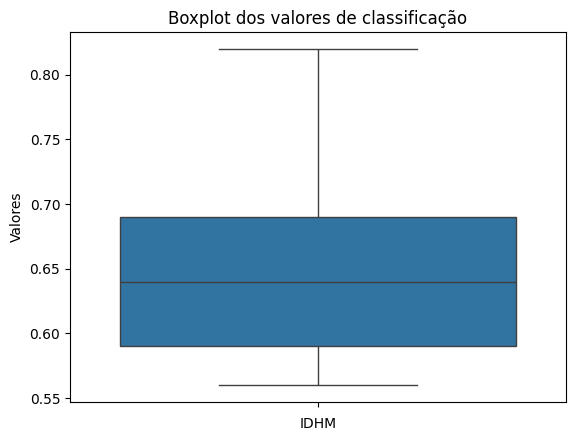

In [23]:
sns.boxplot(y= df_estado['IDHM'] , data= df_estado)

plt.title("Boxplot dos valores de classificação")
plt.xlabel('IDHM')
plt.ylabel('Valores');

In [ ]:
df_estado.head()

,state,IDHM,classe
0,Acre,0.59,Médio desenvolvimento humano
1,Alagoas,0.56,Médio desenvolvimento humano
2,Amapá,0.64,Médio desenvolvimento humano
3,Amazonas,0.57,Médio desenvolvimento humano
4,Bahia,0.59,Médio desenvolvimento humano


In [31]:
import plotly.io as pio
pio.renderers.default = "browser"

fig = px.bar(df_estado, x='state', y='IDHM', color='classe', title='IDHM por estado', color_discrete_sequence = ['green','orange'])
fig.show()